In [1]:
import numpy as np
import pandas as pd

import torch
from torch.utils.data import DataLoader
from torchinfo import summary

import h5py
import scipy.stats
from scipy.stats import median_abs_deviation

from matplotlib import rcParams
rcParams["font.sans-serif"] = ["IBM Plex Sans"]
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Construct variants training and validation datasets

In [2]:
variants = pd.read_parquet(
    "/net/seq/data2/projects/sabramov/ENCODE4/dnase-cavs.v4/output/non_aggregated.all.parquet"
)

In [3]:
variants["total_counts"] = variants.ref_counts + variants.alt_counts

passed_read_count = variants.total_counts > 30
signif = (variants.FDR_sample < 0.1) & (variants.logit_es.abs() < 6)
neg = variants.FDR_sample > 0.5

positives = variants[passed_read_count & signif]
negatives = variants[passed_read_count & neg].sample(n=len(positives))

examples = pd.concat([positives, negatives])

In [ ]:
bins = np.linspace(-5, 5, 100)
h = plt.hist(positives.logit_es, bins=bins)
h = plt.hist(negatives.logit_es, bins=bins, color="red", alpha=0.3)
plt.xlabel("LFC variant effect")

### Sample training and validation samples

In [6]:
columns = [
    "#chr",
    "start",
    "ref",
    "alt",
    "ref_counts",
    "total_counts",
    "BAD",
    "logit_es",
    "sample_id",
    "FDR_sample",
]

dataset = examples[columns].rename(columns={"#chr": "chrom", "start": "pos"})

train_df = dataset.sample(frac=0.9, random_state=1)
valid_df = dataset.drop(train_df.index)

train_df.shape, valid_df.shape

((589905, 10), (65545, 10))

### Write datasets to H5 files

In [2]:
def df_to_h5(path, df: pd.DataFrame):
    with h5py.File(path, "w") as f:
        for column in df.columns:
            data = df[column].values

            if pd.api.types.is_object_dtype(df[column]) or pd.api.types.is_string_dtype(
                df[column]
            ):
                data = data.astype("S30")  # fixed-length byte strings

            f.create_dataset(column, data=data)


## loading df from h5
def df_from_h5(path):
    with h5py.File(path, "r") as f:
        data = {}
        for key in f.keys():
            arr = f[key][:]
            # Decode byte strings if needed
            if arr.dtype.kind == "S":
                arr = arr.astype(str)
            data[key] = arr
        return pd.DataFrame(data)

In [8]:
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.train.h5", train_df)
df_to_h5("/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.h5", valid_df)

# Testing, dataloader, model & loss function

In [2]:
from vinson.dataset import VariantEmbeddingDataset
from vinson.loss import binomial_mixture_loss, binomial_mixture_nll
from vinson.model import (
    CellEmbedding,
    BassetTrunkEmbed,  
    VariantEmbedModel, 
    VariantEmbedModelWrapper)

# Create model
embed = CellEmbedding(n_inputs=637, n_layers=1)
trunk = BassetTrunkEmbed(embed.n_outputs)
model = VariantEmbedModel(trunk, embed)

### Load in dataset and dataloader

In [3]:
examples_file = "/home/jvierstra/proj/vinson/data/dnase-cavs.v4.val.h5"

embeddings_file = "/home/jvierstra/proj/vinson/data/embeddings.tsv"
read_depth_file = "/net/seq/data2/projects/sabramov/SuperIndex/hotspot3/w_babachi_new.v23/ml_prediction/JUL10//continious_annotation/total_cutcounts.tsv"

fasta_file = "/net/seq/data/genomes/human/GRCh38/noalts/GRCh38_no_alts.fa"

dataset = VariantEmbeddingDataset(
    examples_file,
    embeddings_file,
    fasta_file,
    reverse_complement=True,
    jitter=0,
    noise=0,
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)

Opening samples file...
Loading embeddings...
Done!


### Explore loss function

In [4]:
# Select a variant
variant = dataset[340]

# Read counts over variant
total_counts = torch.tensor(variant["total_counts"])
ref_counts = torch.tensor(variant["ref_counts"])
bad_score = torch.tensor(variant["bad_score"])  # BAD score
#tau = torch.tensor(0.5 * np.log(2))
tau = -1 # removes prior

# Observed log-fold change
lfc = torch.log(ref_counts / (total_counts - ref_counts))

# Cycle through LFC values to simulate gradient search
pred_lfc_logit = torch.linspace(-10, 10, 10_000)

nll = binomial_mixture_loss(
    pred_lfc_logit, 
    ref_counts,
    total_counts,
    bad_score,
    tau=tau, 
    reduction="none"
)

print(f"ref_counts = {ref_counts}")
print(f"total_counts = {total_counts}")
print(f"bad = {bad_score}")
print(f"tau = {tau}")
print(f"lfc min nll = {pred_lfc_logit[nll.argmin()]}")
print(f"lfc raw = {lfc}")

ref_counts = 43
total_counts = 52
bad = 1.5
tau = -1
lfc min nll = 1.847184419631958
lfc raw = 1.5639755725860596


Text(0.5, 1.0, 'Loss landscape for a single variant')

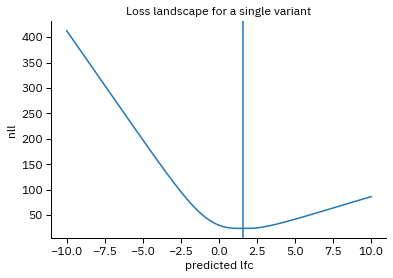

In [5]:
plt.plot(pred_lfc_logit, nll)
plt.axvline(lfc)

plt.xlabel("predicted lfc")
plt.ylabel("nll")

plt.title("Loss landscape for a single variant")

# Train model

To train model edit and run the following script: ```sbatch train_variants.sh```

# Analyze, predict & interpret model

### Load in trunk pre-trained from the DHS model

In [6]:
pretrained_state_dict = torch.load(
    "models/regression_data_JUL10.batch1_v3_poisson/checkpoints/last.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

trunk_pretrained = {k: v for k, v in pretrained_state_dict.items() if "trunk." in k}

### Load in pre-trained variant model

In [7]:
pretrained_state_dict = torch.load(
    "models/variant_v2/checkpoints/last.ckpt",
    map_location=torch.device("cpu"),
)["state_dict"]

# Hack since we refactored model layout
embed_pretrained_state_dict = {
    k.replace("trunk.embed", "embedding"): v 
    for k, v in pretrained_state_dict.items()
    if "trunk.embed" in k
}

In [8]:
model_dict = model.state_dict()
model_dict.update(pretrained_state_dict)
model_dict.update(embed_pretrained_state_dict)

model.load_state_dict(model_dict, strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['trunk.embed.ifc.weight', 'trunk.embed.ifc.bias', 'trunk.embed.fcs.0.weight', 'trunk.embed.fcs.0.bias', 'trunk.embed.ffc.weight', 'trunk.embed.ffc.bias'])

### Predict variants (random batch)

In [9]:
batch = next(iter(dataloader))

X_seq_ref, X_seq_alt, X_embed, ref_counts, total_counts, bad_score = (
    batch["seq_ref"],
    batch["seq_alt"],
    batch["embed"],
    batch["ref_counts"],
    batch["total_counts"],
    batch["bad_score"],
)

# Estimated log-fold change
lfc = (ref_counts / (total_counts - ref_counts)).log()

# Predict example with model
y = model(X_seq_ref, X_seq_alt, X_embed).squeeze()

# Can evaluate different tau values -- -1 removes prior
tau = 0.5 * torch.tensor(2).log()
tau = -1

# Compute loss
loss = binomial_mixture_loss(
    y, ref_counts, total_counts, bad_score, tau=tau, reduction="none"
)

print(f"loss = {loss.mean()}")

loss = 44.06074915252431


Text(0.5, 1.0, 'Loss landscape for batch')

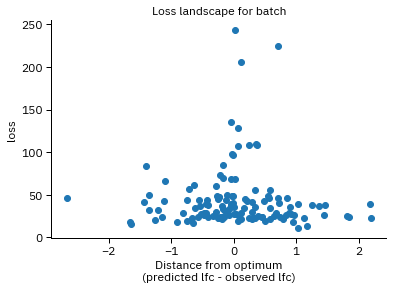

In [10]:
plt.scatter(y.detach() - lfc, loss.detach())
plt.xlabel("Distance from optimum\n(predicted lfc - observed lfc)")
plt.ylabel("loss")

plt.title("Loss landscape for batch")

### Plot the predicted vs. observed LFC 

Text(0.5, 1.0, 'Variant effect prediction from DNA sequence')

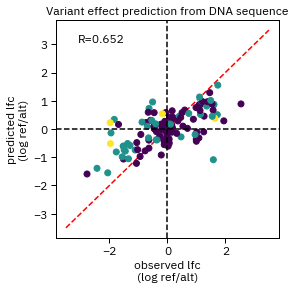

In [11]:
m, b = np.polyfit(lfc, y.detach(), 1)
pearsonr = scipy.stats.pearsonr(lfc, y.detach())

#plt.scatter(lfc, y.detach() * 1 / m + b, c=bad_score)
plt.scatter(lfc, y.detach(), c=bad_score)

plt.axvline(0, ls="--", color="k")
plt.axhline(0, ls="--", color="k")

plt.plot([-3.5, 3.5], [-3.5, 3.5], color="red", ls="--", zorder=-1)

# plt.xlim(-4.5, 4.5)
# plt.ylim(-4.5, 4.5)

[plt.gca().spines[loc].set_visible(True) for loc in ["top", "right"]]

t = plt.text(
    0.1,
    0.9,
    f"R={pearsonr.statistic:0.3f}",
    fontdict=dict(fontsize="large"),
    transform=plt.gca().transAxes,
)

# c = Circle((0,0), 1, fc="lightgrey", alpha=0.75)
# plt.gca().add_patch(c)

plt.gcf().set_size_inches(4, 4)

plt.xlabel("observed lfc\n(log ref/alt)")
plt.ylabel("predicted lfc\n(log ref/alt)")

plt.title("Variant effect prediction from DNA sequence")

### Contribution scores

In [15]:
import vinson.interpretation as interpret
from tangermeme.deep_lift_shap import deep_lift_shap

# You have to wrap the model and deep copy trunk and
# shared input tensors, otherwise DeepLIFT/SHAP
# does not converge.

inference_model = VariantEmbedModelWrapper(model)

In [13]:
i = torch.where(y<-0.65)[0]
i, lfc[i]

(tensor([  7,  10,  19,  20,  28,  38,  40,  41,  48,  53,  68,  70,  93, 103,
         105, 115, 126]),
 tensor([-1.5163, -1.3437, -0.9420, -0.2113, -2.0584, -1.4523, -1.7636, -1.1124,
         -2.7726, -0.7701,  1.5841, -1.4917, -1.5581, -2.4277, -1.0259, -1.0678,
         -0.6376]))

In [27]:
i = 70

In [28]:
# This command shuffles the sequences but keeps the 
# variants constant
references_ = interpret.dinucleotide_shuffle_variant(
    X_seq_ref[i:i+1], X_seq_alt[i:i+1], n=20)

attribs_ref = deep_lift_shap(
    inference_model,
    X_seq_ref[i:i+1],
    args=(X_seq_alt[i:i+1], X_embed[i:i+1],),
    device="cpu",
    print_convergence_deltas=True,
    references=references_[0]
)

attribs_alt = deep_lift_shap(
    inference_model,
    X_seq_alt[i:i+1],
    args=(X_seq_ref[i:i+1], X_embed[i:i+1],),
    device="cpu",
    print_convergence_deltas=True,
    references=references_[1]
)

tensor([1.1921e-07, 4.7684e-07, 9.5367e-07, 1.1921e-07, 2.0266e-06, 7.1526e-07,
        0.0000e+00, 0.0000e+00, 4.7684e-07, 3.5763e-07, 4.7684e-07, 1.4901e-07,
        2.3842e-07, 2.0266e-06, 1.1921e-07, 2.3842e-07, 1.1921e-07, 1.7881e-06,
        1.1921e-06, 9.5367e-07], grad_fn=<AbsBackward0>)
tensor([2.3842e-07, 9.5367e-07, 9.5367e-07, 8.3447e-07, 0.0000e+00, 2.3842e-06,
        4.7684e-07, 4.1723e-07, 1.9073e-06, 4.7684e-07, 2.3842e-07, 3.5763e-07,
        7.4506e-08, 1.1921e-06, 5.9605e-08, 4.7684e-07, 7.1526e-07, 4.7684e-07,
        9.5367e-07, 2.3842e-07], grad_fn=<AbsBackward0>)


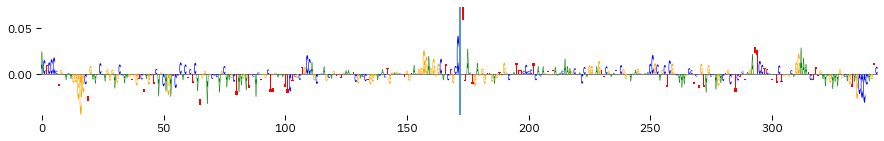

In [29]:
from tangermeme.plot import plot_logo

plot_logo(-(attribs_ref[0]-attribs_alt[0])[:,500:-500])

plt.gcf().set_size_inches(15, 2)
plt.axvline(172)